# Point Net Experimental

In this notebook I will explore the [PointNet](https://arxiv.org/abs/1612.00593) architecture in order to understand how it works. It seems for classification, the model ```PointNetCls``` and for segmentation the model ```PointNetDenseCls``` is used. There are other variants of models (```PointNetfeat```, ```STNkd```, ```STN3d```). As it is the simpler model, we will start with the classification model.

## PointNetCls

In [5]:
import torch

In [6]:
batchSize = 32
num_points = 2500
workers = 4
nepoch = 250
outf  = 'cls' # output folder
model = ''
dataset = '' # dataset path
dataset_type = 'shapenet'
feature_transform = True

In [7]:
blue = lambda x: '\033[94m' + x + '\033[0m'
print(blue("Lol das ist ja in blau!")) 

Lol das ist ja in blau!


In [8]:
manualSeed = 42
torch.manual_seed(manualSeed)

After setting preliminary stuff, first a dataset has to be created using the ```ShapeNetDataset``` class. It will be implemented here

START WITH NEW GITHUB REPO Pointnet_Pointnet2_pytorch which contains both pointnet models but in pytorch!!
Especially look out for the final layers and the how to change the loss to regression.


# PointNet from Pointnet_Pointnet2

Starting with the new repo, we will go through PointNet in order to understand how the latent representation z can be reconstructed. Therefore we will scrutinize the ```train_classification.py``` file using the ```pointnet_cls.py``` model.

The classification script works as follows:
- Check Cuda devices
- Create experiment logging directory
- Create a logger for detailed logging info
- Load the data -> data output format is: point_set, target_class_label -> **We have to adapt the dataloader** so output is: point_set, latent_vector
- Then the model and loss are loaded, also the python files necessary for training are copied into the experiment directory -> **Here we have to change the loss to MSE**
- Then the script checks for checkpoints and initializes Adam optimizer and learning rate scheduler

#### Training
- Before being processed, the points are randomly droped out, scaled and shifted (Why?)
- Then they are processed by the Classifier
- The ```PointNetEncoder``` produces the global feature vector and contains the important model architecture -> **One can take this encoder and use it for DeepCAD**
- First the encoder predicts a matrix for affine transformation of the point features (T-Net) -> This transformation matrix is part of the loss calculation, where the loss tries to keep the transformation matrices as orthogonal as possible ($A \cdot A^T = I$)
- Then a per point MLP/1D Convolution per point (same as MLP) is applied to increase feature space and another transformation matrix is predicted -> Actually only this one goes into the loss, not the point features
- Finally you get the global feature vector

#### Next steps
- Understand pointnet++ (or try first with simpler pointnet?)
- Change loss to MSE regression loss
- Change data to: Input->PC, Target -> Latent vector
- Find a good workflow, i.e. Should I just copy the important code parts from the github repo or should I fork and change some things? What are best practices?

# PointNet++ from Pointnet_Pointnet2

After understanding how PointNet works, let's scrutinize its successor PointNet++. In contrast to its predecessor, PointNet++ uses a hierarchical structure to obtain the global feature vector, thereby putting more emphasis on local features. The setup script has the same structure as in PointNet which is why we will start by looking at the training.

### Training
- The script first checks if the points contain normals or not. In our case we will have no normals. The points are sent to the first _set abstraction_ layer

#### Set abstraction layer 1
- Then centroid points need to be sampled using iterative farthest point sampling (FPS) -> This algorithm basically always chooses the point which is the furthest away from a set of points and results in a good coverage of the point cloud with centroid points -> Result: For each batch sample you get a specific number of centroid points with their index
- Then the script retrieves the coordinates of the points behind the sampled centroid indices
- Next, the indices of the points within a specified radius of each centroid points are found and the coordinates are retrieved
- Thereby you have the following final shape of the data: [B, npoint, nsample, C]
    - _B_: Batch size
    - _npoint_: Number of centroid points
    - _nsample_: Number of points within a certain radius to each centroid point
    - _C_: Coordinates
- The script then calculates the norm between the grouped points and their respective centroid point
- Finally the centroid points and the norm of the grouped points to the centroid points are returned

#### 1D Convolution/Fully Connected Layers
- 1D convolutions (three with output size: 64,64,128) with a kernel of size 1x1 are applied on the norm of the grouped points
    - this is equivalent to applying a fully connected layer on the 3 coordinates of each point of the norm
    - the output has then instead of 3 channels 128 channels
- Then the symmetric function (max) is applied so that we can find the most meaningful features from the _nsample_ points which are within a radius to the centroid points -> **The convolutions and the max functions basically resemble the original PointNet**
- Returned are the centroid points with their coordinates and the features from the norm (now 128 channels)

### Next set abstraction layer
- in the next sa layer, the obtained centroids and the norm with enhanced channels are passed
- Again FPS collects centroid points and ball query finds points within a radius of that and finally the norm is calculated
- The **difference** is now, that we have the extracted (maximum) features of each centroid point of the stage before
- The script now concatenates the new calculated norm (3 coordinates) with the enhanced features of the points lying within a radius to the centroid points (128 features) (those points were centroid points in the previous stage)
- In the final set abstraction layer, no further centroid points are sampled and no grouping takes place
- Only the final centroid points are concatenated with the point embeddings, which are returned and processed by the convolutional layers and the max function, resulting in a 1024 dimensional vector for each point cloud (The point dimension is collapsed due to the max function)

### Final linear layers
- The 1024 dimensional vector per batch sample is processed by 3 fully connected layers to get the final prediction

### Farthest Point sampling
The algorithm is quite simple. You start with a point cloud comprising N points and iteratively select a point until you have up to S samples. You have two sets which we will denote sampled and remaining and you choose a point as follows:
- For each point in remaining find its nearest neighbour in sampled, saving the distance.
- Select the point in remaining whose nearest neighbour distance is the largest and move it from remaining to sampled.


In [9]:
def farthest_point_sample(xyz, npoint):
    """
    Input:
        xyz: pointcloud data, [B, N, 3]
        npoint: number of samples
    Return:
        centroids: sampled pointcloud index, [B, npoint]
    """
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long)
    print(f"Initialise {npoint} centroids indices with zeros:", centroids.shape)
    distance = torch.ones(B, N) * 1e10
    print(f"Initialise distance for {N} points with infinity:", distance.shape)
    farthest = torch.randint(0, N, (B,), dtype=torch.long)
    print(f"Randomly choose the index of the first farthest point:", farthest.item(), ",", xyz[0, farthest, :].view(B, 1, 3), "\n")
    batch_indices = torch.arange(B, dtype=torch.long)
    for i in range(npoint):
        centroids[:, i] = farthest
        print(f"Assign the randomly chosen farthest point as the {i} centroid:", centroids)
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        print(f"Calculate the square distance of the {i} centroid to all other points:")
        dist = torch.sum((xyz - centroid) ** 2, -1)
        print_tensor_grid(dist.squeeze(0))
        mask = dist < distance
        print(f"Mark all points which have a smaller distance than the farthest point.")
        print_tensor_grid(mask.squeeze(0))
        distance[mask] = dist[mask]
        print(f"For all points with a smaller distance than farthest point, parse the distance.")
        print_tensor_grid(distance.squeeze(0))
        farthest = torch.max(distance, -1)[1]
        print("Select the farthest one: ", farthest, xyz[0, farthest, :].view(B, 1, 3), "\n")
    return centroids

In [10]:
xyz = create_grid_point_cloud(int(100**0.5))
fps_idx = farthest_point_sample(xyz, 3)

NameError: name 'create_grid_point_cloud' is not defined

In [11]:
xyz.shape, fps_idx.shape

NameError: name 'xyz' is not defined

In [12]:
def farthest_point_sample(xyz, npoint):
    """
    Input:
        xyz: pointcloud data, [B, N, 3]
        npoint: number of samples
    Return:
        centroids: sampled pointcloud index, [B, npoint]
    """
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def index_points(points, idx):
    """

    Input:
        points: input points data, [B, N, C]
        idx: sample index data, [B, S]
    Return:
        new_points:, indexed points data, [B, S, C]
    """
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    new_points = points[batch_indices, idx, :]
    return new_points

def square_distance(src, dst):
    """
    Calculate Euclid distance between each two points.

    src^T * dst = xn * xm + yn * ym + zn * zm；
    sum(src^2, dim=-1) = xn*xn + yn*yn + zn*zn;
    sum(dst^2, dim=-1) = xm*xm + ym*ym + zm*zm;
    dist = (xn - xm)^2 + (yn - ym)^2 + (zn - zm)^2
         = sum(src**2,dim=-1)+sum(dst**2,dim=-1)-2*src^T*dst

    Input:
        src: source points, [B, N, C]
        dst: target points, [B, M, C]
    Output:
        dist: per-point square distance, [B, N, M]
    """
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def query_ball_point(radius, nsample, xyz, new_xyz):
    """
    Input:
        radius: local region radius
        nsample: max sample number in local region
        xyz: all points, [B, N, 3]
        new_xyz: query points, [B, S, 3]
    Return:
        group_idx: grouped points index, [B, S, nsample]
    """
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).to(device).view(1, 1, N).repeat([B, S, 1])
    sqrdists = square_distance(new_xyz, xyz)
    group_idx[sqrdists > radius ** 2] = N
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat([1, 1, nsample])
    mask = group_idx == N
    group_idx[mask] = group_first[mask]
    return group_idx

In [136]:
B = 1
S = 20
C = 3

xyz = torch.rand(B,100,C)
print(f"xyz\t\t\tPoint cloud with 100 points (bs={B}): {xyz.shape}")

fps_idx = farthest_point_sample(xyz, S)
print(f"fps_idx\t\t\tIndices of {S} centroid points: {fps_idx.shape}")

new_xyz = index_points(xyz, fps_idx)
print(f"new_xyz\t\t\tCoordinates of the {S} centroid points: {new_xyz.shape}")

idx = query_ball_point(0.2, 32, xyz, new_xyz)
print(f"idx\t\t\tIndices of 32 points within a 0.2 radius to the centroid points: {idx.shape}")

grouped_xyz = index_points(xyz, idx)
print(f"grouped_xyz\t\tCoordinates of the 32 points within a 0.2 radius to the centroid points: {grouped_xyz.shape}")

grouped_xyz_norm = grouped_xyz - new_xyz.view(B, S, 1, C)
print(f"grouped_xyz_norm\tSubstract the coordinates of the centroid points from the grouped points to get the norm: {grouped_xyz_norm.shape}")

xyz			Point cloud with 100 points (bs=1): torch.Size([1, 100, 3])
fps_idx			Indices of 20 centroid points: torch.Size([1, 20])
new_xyz			Coordinates of the 20 centroid points: torch.Size([1, 20, 3])
idx			Indices of 32 points within a 0.2 radius to the centroid points: torch.Size([1, 20, 32])
grouped_xyz		Coordinates of the 32 points within a 0.2 radius to the centroid points: torch.Size([1, 20, 32, 3])
grouped_xyz_norm	Substract the coordinates of the centroid points from the grouped points to get the norm: torch.Size([1, 20, 32, 3])


In [137]:
for a in new_xyz.view(B, S, 1, C)[0]:
    print(a)

tensor([[0.2249, 0.7498, 0.2409]])
tensor([[0.9357, 0.0265, 0.8772]])
tensor([[0.9822, 0.9274, 0.9477]])
tensor([[0.9740, 0.5268, 0.0699]])
tensor([[0.2595, 0.4360, 0.9751]])
tensor([[0.2012, 0.0071, 0.1931]])
tensor([[0.7935, 0.8777, 0.4331]])
tensor([[0.6360, 0.2088, 0.4931]])
tensor([[0.3044, 0.9767, 0.6742]])
tensor([[0.8636, 0.4870, 0.8903]])
tensor([[0.5989, 0.1208, 0.0331]])
tensor([[0.5275, 0.6227, 0.6943]])
tensor([[0.2316, 0.3901, 0.4078]])
tensor([[0.5219, 0.1595, 0.9066]])
tensor([[0.5070, 0.9549, 0.0740]])
tensor([[0.0659, 0.6924, 0.5944]])
tensor([[0.5133, 0.5677, 0.0982]])
tensor([[0.9012, 0.8918, 0.1182]])
tensor([[0.9345, 0.1184, 0.5150]])
tensor([[0.7574, 0.3058, 0.2057]])


In [138]:
new_xyz.shape, new_xyz.view(B, S, 1, C).shape

(torch.Size([1, 20, 3]), torch.Size([1, 20, 1, 3]))

In [141]:
new_xyz[0,0], new_xyz.view(B, S, 1, C)[0,0,0]

(tensor([0.2249, 0.7498, 0.2409]), tensor([0.2249, 0.7498, 0.2409]))

In [142]:
grouped_xyz[0,0]

tensor([[0.0989, 0.7487, 0.1281],
        [0.3090, 0.7916, 0.3911],
        [0.2458, 0.6558, 0.3544],
        [0.3023, 0.7786, 0.1018],
        [0.2249, 0.7498, 0.2409],
        [0.3546, 0.7670, 0.2533],
        [0.2636, 0.8081, 0.0643],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.0989, 0.7487, 0.1281],
        [0.098

In [47]:
grouped_xyz_norm[0,0,1]

tensor([-0.1363, -0.0248, -0.0528])

In [17]:
new_xyz  = new_xyz
new_points = grouped_xyz_norm
new_points.shape

torch.Size([1, 20, 32, 3])

In [18]:
new_points = new_points.permute(0, 3, 2, 1)
new_points.shape

torch.Size([1, 3, 32, 20])

In [19]:
import torch.nn as nn
import torch.nn.functional as F

mlp = [64, 64, 128]
in_channel = 3

mlp_convs = nn.ModuleList()
mlp_bns = nn.ModuleList()
last_channel = in_channel
for out_channel in mlp:
    mlp_convs.append(nn.Conv2d(last_channel, out_channel, 1))
    mlp_bns.append(nn.BatchNorm2d(out_channel))
    last_channel = out_channel

In [20]:
for i, conv in enumerate(mlp_convs):
    print(i, conv)
    bn = mlp_bns[i]
    new_points =  F.relu(bn(conv(new_points)))
new_points.shape

0 Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
1 Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
2 Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))


torch.Size([1, 128, 32, 20])

In [28]:
print(torch.max(new_points, 2))[0]
new_points = torch.max(new_points, 2)[0]
new_points.shape

torch.return_types.max(
values=tensor([[3.7709, 3.7066, 2.8697, 4.3465, 6.2855, 3.4076, 2.9638, 4.3426, 3.6783,
         3.0054, 2.6791, 1.5308, 4.5507, 6.8646, 3.3887, 3.7755, 1.2207, 3.0778,
         3.9068, 0.9160, 1.3015, 2.0468, 3.1899, 1.3468, 4.6179, 3.2711, 3.1252,
         2.8895, 3.2935, 2.6297, 5.6831, 2.3350, 6.4730, 3.8054, 5.3984, 5.6844,
         2.3074, 3.6185, 3.7269, 2.3926, 1.6469, 6.1598, 2.4327, 2.8064, 2.1002,
         3.5213, 5.5333, 1.2613, 1.1152, 3.3899, 2.5988, 2.2854, 2.2068, 3.2509,
         3.5763, 3.3995, 3.4685, 7.0118, 3.3720, 5.2305, 4.1918, 1.7642, 2.7291,
         2.8022, 5.5142, 2.8067, 5.0816, 2.5791, 1.9936, 3.1248, 9.2323, 3.6567,
         5.3250, 2.0683, 2.6115, 2.6562, 2.7931, 3.6702, 2.7851, 2.1325, 2.1082,
         2.0337, 3.1992, 2.6407, 3.4093, 0.9600, 3.0124, 1.8232, 1.0486, 3.6791,
         5.8081, 3.2923, 3.0308, 4.0020, 2.7112, 1.6796, 1.6864, 1.7135, 2.5157,
         2.6897, 2.9731, 4.4152, 6.9003, 2.4428, 2.4043, 2.3901, 2.9973, 2.106

TypeError: 'NoneType' object is not subscriptable

In [81]:
new_xyz = new_xyz.permute(0, 2, 1)
new_xyz.shape

torch.Size([1, 3, 20])

In [82]:
xyz = new_xyz.permute(0, 2, 1)
points = new_points.permute(0, 2, 1)


fps_idx = farthest_point_sample(xyz, S) # [B, npoint, C]
new_xyz = index_points(xyz, fps_idx)
idx = query_ball_point(0.4, 10, xyz, new_xyz)
grouped_xyz = index_points(xyz, idx) # [B, npoint, nsample, C]
grouped_xyz_norm = grouped_xyz - new_xyz.view(B, S, 1, C)

In [83]:
new_xyz.shape

torch.Size([1, 20, 3])

In [84]:
grouped_points = index_points(points, idx)

In [85]:
grouped_points.shape

torch.Size([1, 20, 10, 128])

In [86]:
grouped_xyz_norm.shape

torch.Size([1, 20, 10, 3])

In [88]:
mlp_list = [[64, 64, 128], [128, 128, 256], [128, 128, 256]]
in_channel = 320

conv_blocks = []
bn_blocks = []
for i in range(len(mlp_list)):
    convs = []
    bns = []
    last_channel = in_channel + 3
    for out_channel in mlp_list[i]:
        convs.append((last_channel, out_channel, 1))
        bns.append(out_channel)
        last_channel = out_channel
    conv_blocks.append(convs)
    bn_blocks.append(bns)

In [89]:
conv_blocks

[[(323, 64, 1), (64, 64, 1), (64, 128, 1)],
 [(323, 128, 1), (128, 128, 1), (128, 256, 1)],
 [(323, 128, 1), (128, 128, 1), (128, 256, 1)]]

In [10]:
bn_blocks

[[32, 32, 64], [64, 64, 128], [64, 96, 128]]

In [42]:
mlp_list = [[32, 32, 64], [64, 64, 128], [64, 96, 128]]
in_channel = 0

conv_blocks = nn.ModuleList()
bn_blocks = nn.ModuleList()
for i in range(len(mlp_list)):
    convs = nn.ModuleList()
    bns = nn.ModuleList()
    last_channel = in_channel + 3
    for out_channel in mlp_list[i]:
        convs.append(nn.Conv2d(last_channel, out_channel, 1))
        bns.append(nn.BatchNorm2d(out_channel))
        last_channel = out_channel
    conv_blocks.append(convs)
    bn_blocks.append(bns)

In [43]:
conv_blocks

ModuleList(
  (0): ModuleList(
    (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
    (1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
    (2): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (1): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    (2): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (2): ModuleList(
    (0): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): Conv2d(64, 96, kernel_size=(1, 1), stride=(1, 1))
    (2): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1))
  )
)

In [31]:
a = torch.rand(2,64,512)
b = torch.rand(2,128,512)
lol = [a, b]


In [33]:
torch.cat(lol, dim =1).shape

torch.Size([2, 192, 512])

In [80]:
N = 8096
a = torch.arange(N).view(1, 1, N).repeat([2, 512, 1])
print(a.shape)
a= a.sort(dim=-1)[0][:,:,:3]
print(a.shape)
group_first=a[:,:,0].view(2,512,1)
print(group_first.shape)
group_first = group_first.repeat([1,1,16])
print(group_first.shape)

torch.Size([2, 512, 8096])
torch.Size([2, 512, 3])
torch.Size([2, 512, 1])
torch.Size([2, 512, 16])


In [75]:
a

tensor([[0, 1, 2],
        [0, 1, 2],
        [0, 1, 2],
        ...,
        [0, 1, 2],
        [0, 1, 2],
        [0, 1, 2]])

## PointNet++ by erikwijmans
[Link to repo.](https://github.com/erikwijmans/Pointnet2_PyTorch/commits/master/?after=b5ceb6d9ca0467ea34beb81023f96ee82228f626+34)
This one was used by the authors and in order to obtain the same metrics as them I am analyzing this model to see where it differs from mine

In [44]:
npoint=512
radius=0.1
nsample=64
mlp=[64, 64, 64, 128]
use_xyz = True

In [45]:
mlps=[mlp]
npoint=npoint
radii=[radius]
nsamples=[nsample]

mlps_module_list = nn.ModuleList()

In [46]:
assert len(radii) == len(nsamples) == len(mlps)

In [47]:
import torch
import torch.nn as nn
def build_shared_mlp(mlp_spec, bn= True):
    layers = []
    for i in range(1, len(mlp_spec)):
        layers.append(
            nn.Conv2d(mlp_spec[i - 1], mlp_spec[i], kernel_size=1, bias=not bn)
        )
        if bn:
            layers.append(nn.BatchNorm2d(mlp_spec[i]))
        layers.append(nn.ReLU(True))

    return nn.Sequential(*layers)

In [48]:
for i in range(len(radii)):
    radius = radii[i]
    nsample = nsamples[i]
    print(f"S: {npoint}, K:{nsample}, r: {radius}", end=", ")
    mlp_spec = mlps[i]
    if use_xyz:
        mlp_spec[0] += 3
    print(mlp_spec)
    mlps_module_list.append(build_shared_mlp(mlp_spec, bn= True))

S: 512, K:64, r: 0.1, [67, 64, 64, 128]


In [49]:
print(mlps_module_list)

ModuleList(
  (0): Sequential(
    (0): Conv2d(67, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
)


In [50]:
a= [None]

In [51]:
len(a)

1

## Visualization of PN++

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import os

def create_grid_point_cloud(size):
    # Create 10 evenly spaced values from 0 to 9 for x and y
    x = np.arange(size)
    y = np.arange(size)
    
    # Create a 2D grid of shape (100, 2)
    xx, yy = np.meshgrid(x, y)
    grid = np.stack([xx.ravel(), yy.ravel(), np.zeros(size**2)], axis=-1)  # shape (100, 3)
    
    # Add batch dimension to get shape (1, 100, 3)
    point_cloud = grid[np.newaxis, ...]
    point_cloud = torch.tensor(point_cloud, dtype = torch.float32)
    
    return point_cloud

import torch
import matplotlib.pyplot as plt
import numpy as np

def query_ball_point(radius, nsample, xyz, new_xyz):
    device = xyz.device
    B, N, C = xyz.shape
    _, S, _ = new_xyz.shape
    group_idx = torch.arange(N, dtype=torch.long).view(1, 1, N).repeat([B, S, 1])
    sqrdists = square_distance(new_xyz, xyz)
  #  print("Distances")
   # print(sqrdists)
  #  for a in sqrdists.squeeze(0):
   #     print_tensor_grid(a)
    #    print("\n")
    group_idx[sqrdists > radius ** 2] = N
 #   print(group_idx)
 #   for a in group_idx.squeeze(0):
  #      print_tensor_grid(a)
   #     print("\n")
    group_idx = group_idx.sort(dim=-1)[0][:, :, :nsample]
 #   print(group_idx)
    group_first = group_idx[:, :, 0].view(B, S, 1).repeat([1, 1, nsample])
    mask = group_idx == N
 #   print(mask)
    group_idx[mask] = group_first[mask]
  #  print(group_idx)
    return group_idx

def square_distance(src, dst):
    B, N, _ = src.shape
    _, M, _ = dst.shape
    dist = -2 * torch.matmul(src, dst.permute(0, 2, 1))
    dist += torch.sum(src ** 2, -1).view(B, N, 1)
    dist += torch.sum(dst ** 2, -1).view(B, 1, M)
    return dist

def farthest_point_sample(xyz, npoint):
    """
    Input:
        xyz: pointcloud data, [B, N, 3]
        npoint: number of samples
    Return:
        centroids: sampled pointcloud index, [B, npoint]
    """
    device = xyz.device
    B, N, C = xyz.shape
    centroids = torch.zeros(B, npoint, dtype=torch.long).to(device)
    distance = torch.ones(B, N).to(device) * 1e10
    farthest = torch.randint(0, N, (B,), dtype=torch.long).to(device)
    batch_indices = torch.arange(B, dtype=torch.long).to(device)
    for i in range(npoint):
        centroids[:, i] = farthest
        centroid = xyz[batch_indices, farthest, :].view(B, 1, 3)
        dist = torch.sum((xyz - centroid) ** 2, -1)
        mask = dist < distance
        distance[mask] = dist[mask]
        farthest = torch.max(distance, -1)[1]
    return centroids

def index_points(points, idx):
    """

    Input:
        points: input points data, [B, N, C]
        idx: sample index data, [B, S]
    Return:
        new_points:, indexed points data, [B, S, C]
    """
    device = points.device
    B = points.shape[0]
    view_shape = list(idx.shape)
    view_shape[1:] = [1] * (len(view_shape) - 1)
    repeat_shape = list(idx.shape)
    repeat_shape[0] = 1
    batch_indices = torch.arange(B, dtype=torch.long).to(device).view(view_shape).repeat(repeat_shape)
    new_points = points[batch_indices, idx, :]
    return new_points

def print_tensor_grid(tensor: torch.Tensor):
    """
    Prints a 1D torch tensor of size [100] as a nicely aligned 10x10 table,
    starting from the bottom row (inverted vertical order).
    
    Parameters:
    - tensor: torch.Tensor of shape (100,)
    """
    assert tensor.shape == torch.Size([100]), "Tensor must have shape [100]"
    
    for i in reversed(range(10)):
        row = tensor[i * 10:(i + 1) * 10]
        print("  ".join(f"{x.item():6.2f}" for x in row))


In [460]:
xyz = create_grid_point_cloud(10)
xyz.shape, xyz.dtype

(torch.Size([1, 100, 3]), torch.float32)

In [461]:
fps_idx = farthest_point_sample(xyz, 3)
fps_idx,fps_idx.shape, fps_idx.dtype

(tensor([[ 3, 99, 90]]), torch.Size([1, 3]), torch.int64)

In [462]:
new_xyz = index_points(xyz, fps_idx)
new_xyz.shape, new_xyz.dtype

(torch.Size([1, 3, 3]), torch.float32)

In [463]:
idx = query_ball_point(1.1, 6, xyz, new_xyz)
idx.shape

torch.Size([1, 3, 6])

In [464]:
grouped_xyz = index_points(xyz, idx)
grouped_xyz.shape

torch.Size([1, 3, 6, 3])

AHA! Jeder Punkt wird aufsteigend gekennzeichnet mit einem int. Wenn man nun einen radius hat der z.B. 50 Punkte in der Umgebung eines Centroids umfasst, man aber nur 5 Punkte auswählen will, so werden die Punkte sortiert und die ersten 5 genommen. Diese liegen dann natürlich nicht in der Nähe des Centroids, sondern so wie sie numeriert wurden (zum beispiel rowwisse aufsteigend). Daher sollte man immer genügend Punkte auswählen/mehr Punkte als im Radius enthalten. Der Centroid point ist teil der ausgewählten Punkte und wird wiederholt falls nicht genügend Punkte vorhanden sind.

In [50]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle

def plot_tensor_points(base_points: torch.Tensor, 
                       red_points: torch.Tensor = None, 
                       subset_points: torch.Tensor = None,
                       radius: float = None,
                       save: str = None):
    """
    Plots torch tensors of shape (1, N, 3), (1, S, 3), and (1, S, K, 3).
    
    Parameters:
    - base_points: (1, N, 3) torch tensor, all black.
    - red_points: optional (1, S, 3) torch tensor, plotted in red.
    - subset_points: optional (1, S, K, 3) torch tensor, S groups of K points. 
                     Each group has its own color (different from red and black).
    - radius: optional float. If provided, draws red circles around red points with this radius,
              but does not change the plot's field of view (margin of ±1 is added).
    """
    assert base_points.shape[0] == 1 and base_points.shape[2] == 3, "base_points must be of shape (1, N, 3)"
    base_points_np = base_points.squeeze(0).cpu().numpy()
    all_points_2d = [base_points_np[:, :2]]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(base_points_np[:, 0], base_points_np[:, 1], color='black', s=50, label='Points')

    red_points_np = None
    if red_points is not None:
        assert red_points.shape[0] == 1 and red_points.shape[2] == 3, "red_points must be of shape (1, S, 3)"
        red_points_np = red_points.squeeze(0).cpu().numpy()
        all_points_2d.append(red_points_np[:, :2])

    if subset_points is not None:
        assert subset_points.shape[0] == 1 and subset_points.shape[3] == 3, "subset_points must be of shape (1, S, K, 3)"
        subset_points_np = subset_points.squeeze(0).cpu().numpy()
        S = subset_points_np.shape[0]
        cmap = plt.get_cmap("tab10")

        for s in range(S):
            group = subset_points_np[s]
            if red_points_np is not None:
                mask = ~np.any(np.all(np.isclose(group[:, None, :], red_points_np[None, :, :]), axis=2), axis=1)
                group = group[mask]
            if group.shape[0] > 0:
                all_points_2d.append(group[:, :2])
                color = cmap(s % 10)
                ax.scatter(group[:, 0], group[:, 1], color=color, s=50, label=f'Subset {s}')

    # Set fixed limits based on all 2D coordinates with ±1 margin
    all_points_np = np.concatenate(all_points_2d, axis=0)
    x_min, x_max = np.min(all_points_np[:, 0]), np.max(all_points_np[:, 0])
    y_min, y_max = np.min(all_points_np[:, 1]), np.max(all_points_np[:, 1])
    margin = 1.0
    ax.set_xlim(x_min - margin, x_max + margin)
    ax.set_ylim(y_min - margin, y_max + margin)

    # Plot red points and circles after setting the FOV
    if red_points_np is not None:
        ax.scatter(red_points_np[:, 0], red_points_np[:, 1], color='red', s=100, label='Centroids')
        if radius is not None:
            for x, y, _ in red_points_np:
                circle = Circle((x, y), radius, edgecolor='red', facecolor='none', linewidth=3)
                ax.add_patch(circle)

 #   ax.set_title("2D Plot of Point Tensors")
 #   ax.set_xlabel("X")
 #   ax.set_ylabel("Y")
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

 #   ax.legend()
    if save is not None:
        plt.savefig(os.path.join("figures", save + ".png"), dpi=300, bbox_inches='tight')
    plt.show()


In [146]:
N = 1000
S = 1
K = 3
r = 1

In [147]:
xyz = create_grid_point_cloud(int(N**0.5))
fps_idx = farthest_point_sample(xyz, S)
new_xyz = index_points(xyz, fps_idx)
idx = query_ball_point(r, K, xyz, new_xyz)
grouped_xyz = index_points(xyz, idx)

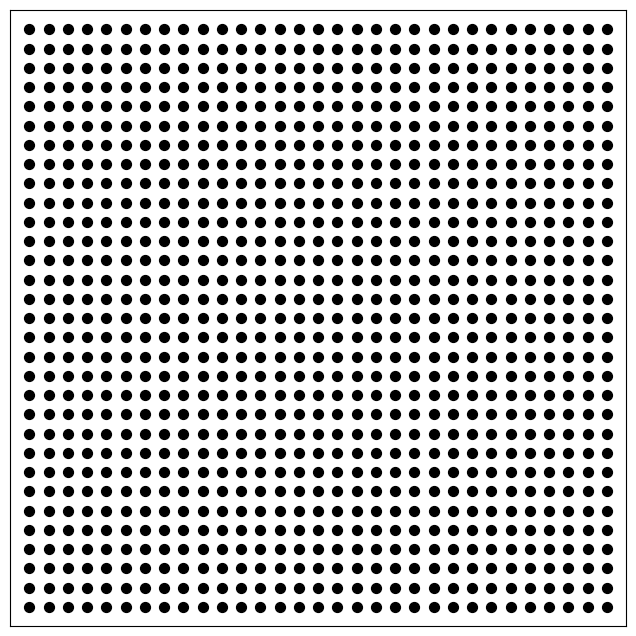

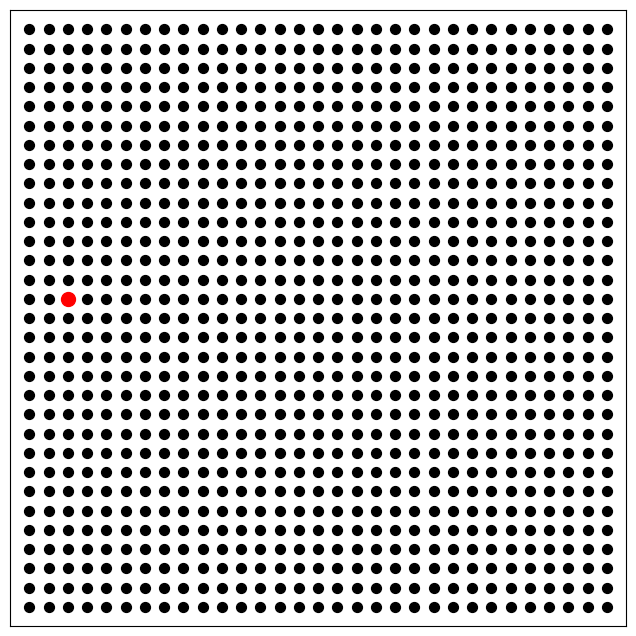

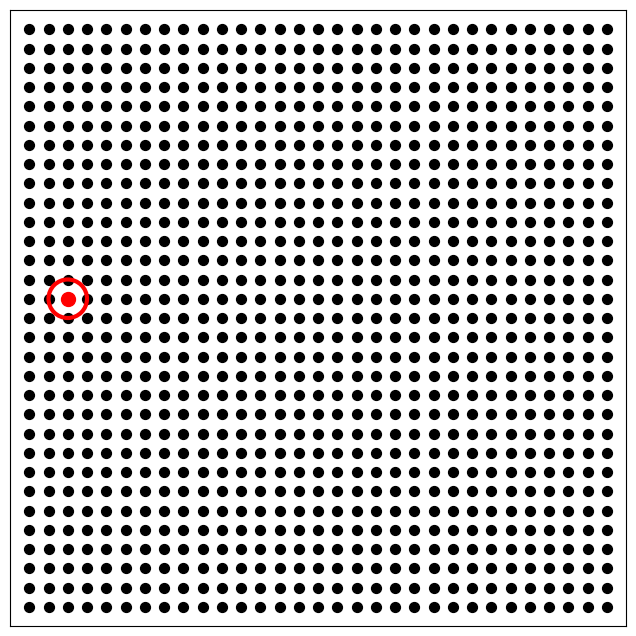

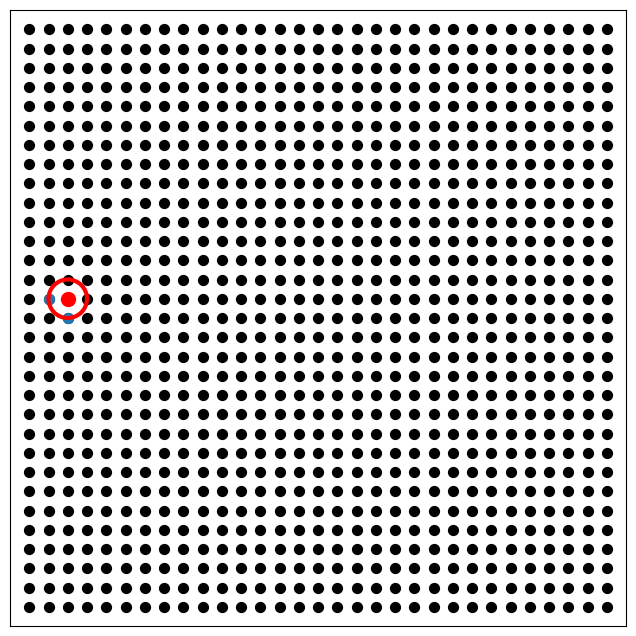

In [148]:
plot_tensor_points(base_points=xyz, 
                   red_points=None, 
                   subset_points=None, #grouped_xyz,
                   radius=None,
                   save="pc")
plot_tensor_points(base_points=xyz, 
                   red_points=new_xyz, 
                   subset_points=None, #grouped_xyz,
                   radius=None,
                   save="centroids")
plot_tensor_points(base_points=xyz, 
                   red_points=new_xyz, 
                   subset_points=None, #grouped_xyz,
                   radius=r,
                   save="radii")
plot_tensor_points(base_points=xyz, 
                   red_points=new_xyz, 
                   subset_points=grouped_xyz,
                   radius=r,
                   save="neighbors")

In [149]:
grouped_xyz[0,0], new_xyz.view(B, S, 1, C)[0,0,0]

(tensor([[ 2., 15.,  0.],
         [ 1., 16.,  0.],
         [ 2., 16.,  0.]]),
 tensor([ 2., 16.,  0.]))

In [128]:
new_xyz.view(B, S, 1, C).shape

torch.Size([1, 5, 1, 3])

In [150]:
a = grouped_xyz - new_xyz.view(B, S, 1, C)

In [152]:
a

tensor([[[[ 0., -1.,  0.],
          [-1.,  0.,  0.],
          [ 0.,  0.,  0.]]]])

In [117]:
S = 10
K = 30
r = 6

In [118]:
fps_idx_2 = farthest_point_sample(new_xyz, S)
new_xyz_2 = index_points(new_xyz, fps_idx_2)
idx_2 = query_ball_point(r, K, new_xyz, new_xyz_2)
grouped_xyz_2 = index_points(new_xyz, idx_2)

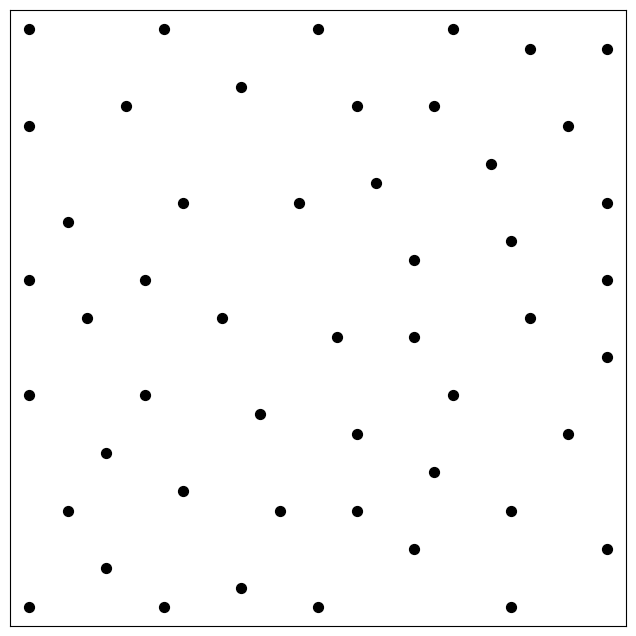

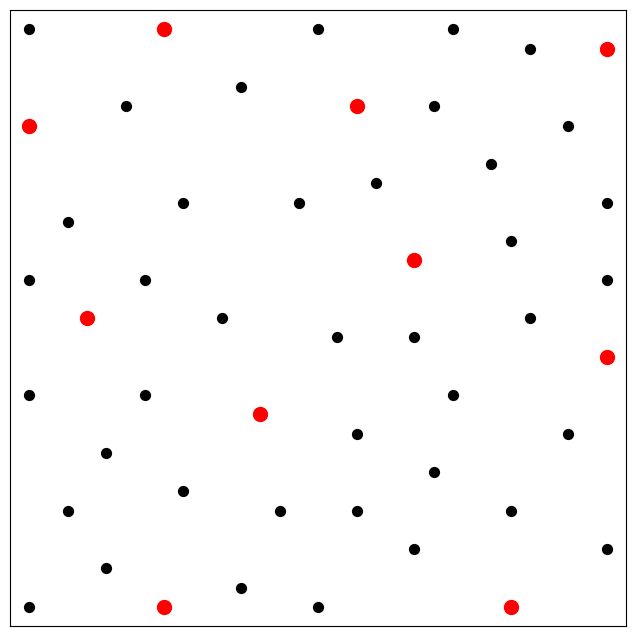

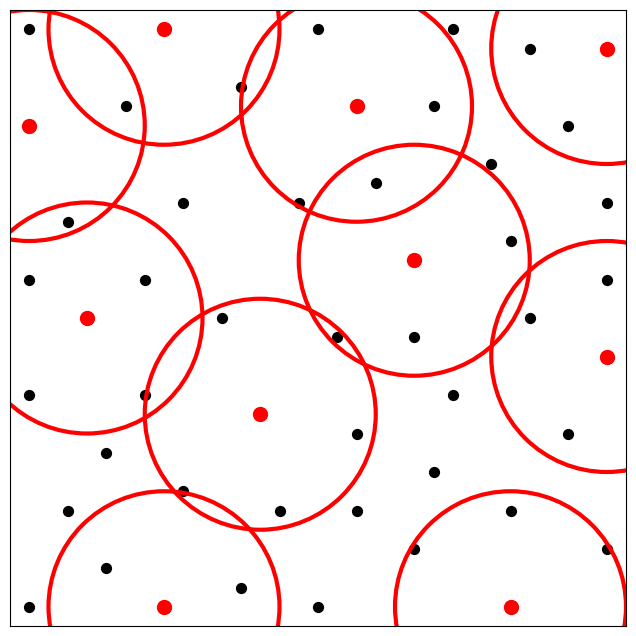

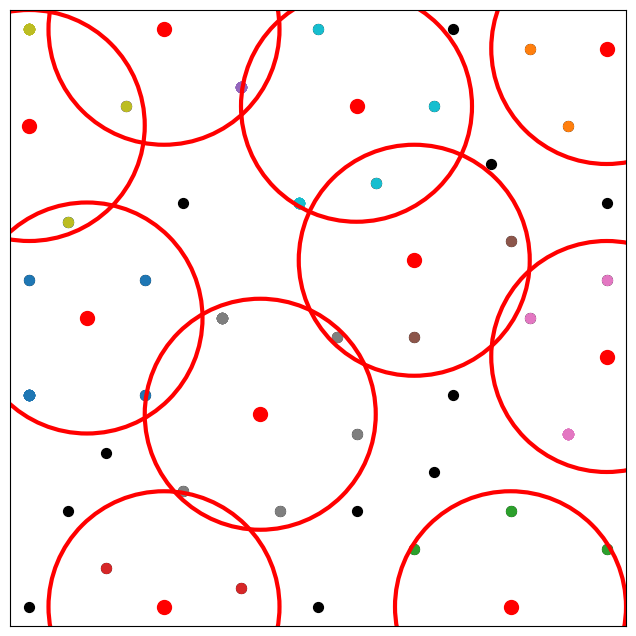

In [119]:
plot_tensor_points(base_points=new_xyz, 
                   red_points=None, 
                   subset_points=None, #grouped_xyz,
                   radius=None,
                   save="pc")
plot_tensor_points(base_points=new_xyz, 
                   red_points=new_xyz_2, 
                   subset_points=None, #grouped_xyz,
                   radius=None,
                   save="centroids")
plot_tensor_points(base_points=new_xyz, 
                   red_points=new_xyz_2, 
                   subset_points=None, #grouped_xyz,
                   radius=r,
                   save="radii")
plot_tensor_points(base_points=new_xyz, 
                   red_points=new_xyz_2, 
                   subset_points=grouped_xyz_2,
                   radius=r,
                   save="neighbors")